<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec07_multinomial_logistic_regression_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 다항 로지스틱 회귀 (Multinomial Logistic Regression) 실습

이 실습에서는 다중 클래스 분류(Multi-class Classification)를 위한 다항 로지스틱 회귀를 학습합니다:
1. sklearn의 LogisticRegression 사용
2. Softmax 함수 직접 구현
3. Cross-Entropy Loss 직접 구현
4. Gradient Descent로 직접 학습

**Softmax 함수:**
$$\text{softmax}(z_k) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

**Categorical Cross-Entropy 손실:**
$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})$$

**총점: 100점**

**학번:** 2023042028\
**이름:** 권택주

In [1]:
#@title { vertical-output: true}
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---
## Part 1: 데이터셋 준비

3개의 클래스를 가진 2D 데이터셋을 생성합니다.

---

### 데이터 생성

make_blobs를 사용하여 3개의 클러스터 데이터를 생성합니다.

X shape: (600, 2)
y shape: (600,)
클래스 분포: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200)}


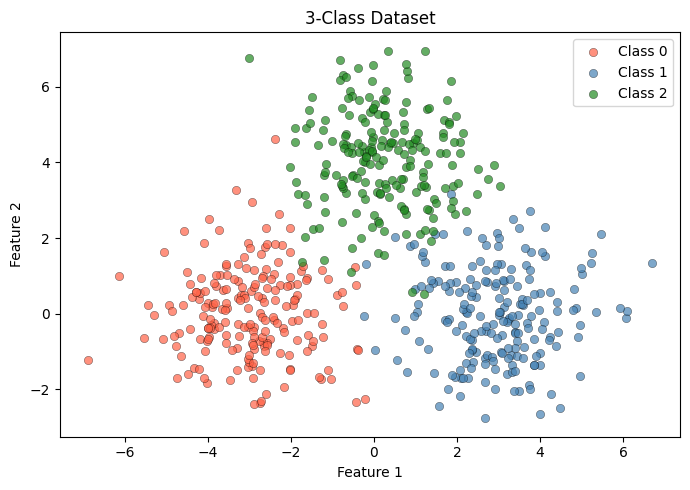

In [2]:
#@title { vertical-output: true}
# 3-class 데이터셋 생성
X, y = make_blobs(n_samples=600, n_features=2,
                  centers=[[-3, 0], [3, 0], [0, 4]],
                  cluster_std=1.2, random_state=42)
n_classes = len(np.unique(y))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"클래스 분포: {dict(zip(*np.unique(y, return_counts=True)))}")

# 시각화
colors = ['tomato', 'steelblue', 'forestgreen']
plt.figure(figsize=(7, 5))
for c in range(n_classes):
    idx = y == c
    plt.scatter(X[idx, 0], X[idx, 1], c=colors[c], label=f'Class {c}', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('3-Class Dataset')
plt.legend()
plt.tight_layout()
plt.show()

### 문제 1-1. 데이터 분할

**문제:** train_test_split을 사용하여 데이터를 분할하세요.

**예상 결과:** 훈련 480개, 테스트 120개

In [4]:
#@title { vertical-output: true}
# IMPLEMENT HERE: train_test_split 사용 (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"훈련 데이터: {X_train.shape[0]}개")
print(f"테스트 데이터: {X_test.shape[0]}개")

훈련 데이터: 480개
테스트 데이터: 120개


---
## Part 2: sklearn LogisticRegression (10점)

sklearn의 LogisticRegression을 사용하여 다중 클래스 분류 모델을 학습합니다.

---

### 문제 2-1. sklearn 모델 학습 [5점]

**문제:** LogisticRegression 모델을 생성하고 학습시키세요. (solver='lbfgs', max_iter=1000)

**예상 결과:** 학습 완료된 모델 출력

In [5]:
#@title { vertical-output: true}
# IMPLEMENT HERE: LogisticRegression 생성 및 학습
model_sk = LogisticRegression(solver='lbfgs', max_iter=1000)
model_sk.fit(X_train, y_train)


print("모델 학습 완료!")
print(f"가중치 (coef) shape: {model_sk.coef_.shape}")
print(f"절편 (intercept): {model_sk.intercept_}")

모델 학습 완료!
가중치 (coef) shape: (3, 2)
절편 (intercept): [ 0.07887449  0.86382276 -0.94269725]


### 문제 2-2. 예측 및 정확도 계산 [3점]

**문제:** 테스트 데이터로 예측하고 정확도를 계산하세요.

**예상 결과:** 정확도 약 0.92 이상

In [7]:
#@title { vertical-output: true}
# IMPLEMENT HERE: 예측
y_hat_sk = model_sk.predict(X_test)

# IMPLEMENT HERE: 정확도 계산
acc_sk = accuracy_score(y_test, y_hat_sk)

print(f'Accuracy (sklearn): {acc_sk:.4f}')

Accuracy (sklearn): 0.9833


### 문제 2-3. 결정 경계 시각화 [2점]

**문제:** plot_decision_boundary 함수의 빈칸을 채워 결정 경계를 시각화하세요.

**예상 결과:** 3개 클래스의 결정 경계가 색으로 구분된 그래프

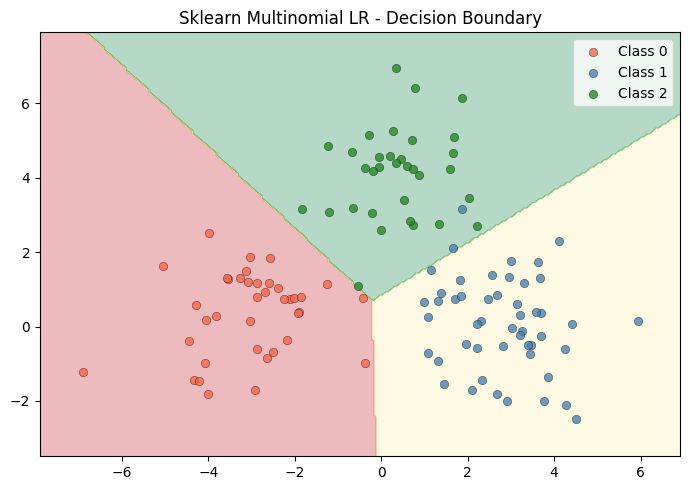

In [8]:
#@title { vertical-output: true}
def plot_decision_boundary(model, X, y, title='Decision Boundary'):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # IMPLEMENT HERE: grid에 대한 예측값 계산
    Z = model.predict(grid)

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    for c in range(3):
        idx = y == c
        plt.scatter(X[idx, 0], X[idx, 1], c=colors[c], label=f'Class {c}',
                    edgecolors='k', linewidths=0.3, alpha=0.8)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_decision_boundary(model_sk, X_test, y_test, title='Sklearn Multinomial LR - Decision Boundary')

---
## Part 3: Softmax 함수 구현 (15점)

Softmax는 K개 클래스에 대한 확률 분포를 출력하는 함수입니다.

$$\text{softmax}(z_k) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

- 입력 Z: $(N \times K)$ — N개 샘플, K개 클래스
- 출력: $(N \times K)$ — 각 행의 합 = 1.0

---

### 문제 3-1. Softmax 함수 구현 [15점]

**문제:** softmax 함수를 구현하세요. 각 원소에 exp를 적용한 후 행별 합으로 나눕니다.

**예상 결과:**
```
Softmax output:
[[0.804 0.049 0.147]
 [0.147 0.049 0.804]
 [0.333 0.333 0.333]]
Row sums (should all be 1.0): [1. 1. 1.]
```

In [10]:
#@title { vertical-output: true}
def softmax(Z):
    """
    Z: ndarray of shape (N, K)
    returns: ndarray of shape (N, K), row-wise probability distribution
    """
    # IMPLEMENT HERE: exp 적용 후 행별 합으로 나누기 (axis=1, keepdims=True)
    exp_Z = np.exp(Z)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

# 테스트
z_test = np.array([[2.8, 0.0, 1.1],
                   [1.1, 0.0, 2.8],
                   [1.0, 1.0, 1.0]])
out = softmax(z_test)
print('Softmax output:')
print(np.round(out, 3))
print('Row sums (should all be 1.0):', out.sum(axis=1).round(6))

Softmax output:
[[0.804 0.049 0.147]
 [0.147 0.049 0.804]
 [0.333 0.333 0.333]]
Row sums (should all be 1.0): [1. 1. 1.]


---
## Part 4: Cross-Entropy Loss 구현 (15점)

**One-Hot Encoding:** 정수 레이블을 벡터로 변환

$$y=1 \quad \Rightarrow \quad \mathbf{y} = [0, 1, 0]$$

**Categorical Cross-Entropy Loss:**

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik} + \varepsilon)$$

---

### 문제 4-1. One-Hot Encoding 구현 [5점]

**문제:** 정수 레이블 배열을 One-Hot 행렬로 변환하는 함수를 구현하세요.

**예상 결과:**
```
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
```

In [11]:
#@title { vertical-output: true}
def to_one_hot(y, n_classes):
    """
    y: 1D array of integer labels, shape (N,)
    n_classes: number of classes K
    returns: one-hot matrix of shape (N, K)
    """
    # IMPLEMENT HERE: np.zeros로 행렬 생성 후 해당 위치에 1 설정
    one_hot = np.zeros((len(y), n_classes))
    one_hot[np.arange(len(y)), y] = 1.0
    return one_hot

# 테스트
y_example = np.array([0, 1, 2, 1, 0])
print('One-hot encoding:')
print(to_one_hot(y_example, 3))

One-hot encoding:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]


### 문제 4-2. Cross-Entropy Loss 구현 [10점]

**문제:** Categorical Cross-Entropy Loss를 구현하세요. log(0) 방지를 위해 eps=1e-8을 더합니다.

**예상 결과:**
```
Loss (near-perfect): ~0.01  (should be near 0)
Loss (wrong): ~2.30  (should be large)
```

In [14]:
#@title { vertical-output: true}
def cross_entropy_loss(Y_true, Y_hat):
    """
    Y_true: one-hot matrix, shape (N, K)
    Y_hat : predicted probabilities, shape (N, K)
    returns: scalar mean cross-entropy loss
    """
    eps = 1e-8
    # IMPLEMENT HERE: -sum(Y_true * log(Y_hat + eps)) / N
    loss = -np.sum(Y_true * np.log(Y_hat + eps)) / Y_true.shape[0]
    return loss

# 테스트
Y_true_ex = np.array([[1,0,0],[0,1,0],[0,0,1]], dtype=float)
Y_hat_perfect = np.array([[0.99,0.005,0.005],[0.005,0.99,0.005],[0.005,0.005,0.99]])
Y_hat_wrong   = np.array([[0.1,0.8,0.1],[0.1,0.1,0.8],[0.8,0.1,0.1]])
print(f'Loss (near-perfect): {cross_entropy_loss(Y_true_ex, Y_hat_perfect):.4f}  (should be near 0)')
print(f'Loss (wrong):        {cross_entropy_loss(Y_true_ex, Y_hat_wrong):.4f}   (should be large)')

Loss (near-perfect): 0.0101  (should be near 0)
Loss (wrong):        2.3026   (should be large)


---
## Part 5: Gradient 계산 및 학습 루프 (30점)

**모델 구조:** $Z = XW + b$, $\hat{Y} = \text{softmax}(Z)$

**Gradient:**

$$\frac{\partial \mathcal{L}}{\partial Z} = \hat{Y} - Y_{\text{true}}, \quad \frac{\partial \mathcal{L}}{\partial W} = \frac{1}{N} X^T \cdot \frac{\partial \mathcal{L}}{\partial Z}, \quad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{N} \sum \frac{\partial \mathcal{L}}{\partial Z}$$

---

### 문제 5-1. Forward Pass 구현 [10점]

**문제:** 선형 변환 후 Softmax를 적용하는 forward 함수를 구현하세요.

**예상 결과:** Z shape (N, K), Y_hat shape (N, K), Y_hat 각 행의 합 = 1.0

In [15]:
#@title { vertical-output: true}
def forward(X, W, b):
    """
    X: (N, d),  W: (d, K),  b: (1, K)
    returns Z (N, K),  Y_hat (N, K)
    """
    # IMPLEMENT HERE: Z = X @ W + b
    Z = X @ W + b
    # IMPLEMENT HERE: Y_hat = softmax(Z)
    Y_hat = softmax(Z)
    return Z, Y_hat

### 문제 5-2. Gradient 계산 구현 [10점]

**문제:** dW와 db를 계산하는 compute_gradient 함수를 구현하세요.

**예상 결과:** dW shape (d, K), db shape (1, K)

In [16]:
#@title { vertical-output: true}
def compute_gradient(X, Y_true, Y_hat):
    """
    X:      (N, d)
    Y_true: (N, K)  — one-hot labels
    Y_hat:  (N, K)  — softmax predictions
    returns dW (d, K),  db (1, K)
    """
    N = X.shape[0]
    # IMPLEMENT HERE: dZ = Y_hat - Y_true
    dZ = Y_hat - Y_true
    # IMPLEMENT HERE: dW = X.T @ dZ / N
    dW = X.T @ dZ / N
    # IMPLEMENT HERE: db = dZ.mean(axis=0, keepdims=True)
    db = dZ.mean(axis=0, keepdims=True)
    return dW, db

### 문제 5-3. 학습 루프 구현 [10점]

**문제:** forward, compute_gradient를 사용하여 Gradient Descent로 W, b를 업데이트하는 학습 루프를 완성하세요.

**예상 결과:** Epoch 500에서 Loss < 0.10

In [17]:
#@title { vertical-output: true}
def train_multinomial_lr(X_train, y_train, n_classes,
                          learning_rate=0.1, n_epochs=500, verbose=True):
    N, d = X_train.shape
    K    = n_classes

    np.random.seed(0)
    W = np.random.randn(d, K) * 0.01
    b = np.zeros((1, K))

    Y_true = to_one_hot(y_train, K)
    loss_history = []

    for epoch in range(n_epochs):
        # IMPLEMENT HERE: Forward pass
        _, Y_hat = forward(X_train, W, b)
        # IMPLEMENT HERE: Loss 계산
        loss = cross_entropy_loss(Y_true, Y_hat)
        # IMPLEMENT HERE: Gradient 계산
        dW, db = compute_gradient(X_train, Y_true, Y_hat)
        # IMPLEMENT HERE: Weight 업데이트
        W -= learning_rate * dW
        b -= learning_rate * db
        loss_history.append(loss)

        if verbose and (epoch + 1) % 100 == 0:
            print(f'Epoch {epoch+1:4d} | Loss: {loss:.4f}')

    return W, b, loss_history

# 학습 실행
W, b, loss_history = train_multinomial_lr(
    X_train, y_train, n_classes=3,
    learning_rate=0.1, n_epochs=500
)

Epoch  100 | Loss: 0.1167
Epoch  200 | Loss: 0.0982
Epoch  300 | Loss: 0.0910
Epoch  400 | Loss: 0.0871
Epoch  500 | Loss: 0.0847


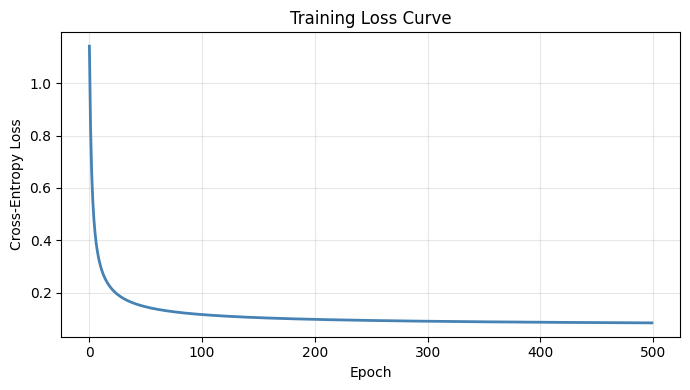

Accuracy (Scratch): 0.9750
Accuracy (sklearn): 0.9833


In [18]:
#@title { vertical-output: true}
# 학습 곡선 시각화
plt.figure(figsize=(7, 4))
plt.plot(loss_history, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 테스트셋 정확도
_, Y_hat_test = forward(X_test, W, b)
y_hat_scratch = np.argmax(Y_hat_test, axis=1)
acc_scratch = accuracy_score(y_test, y_hat_scratch)
print(f'Accuracy (Scratch): {acc_scratch:.4f}')
print(f'Accuracy (sklearn): {acc_sk:.4f}')

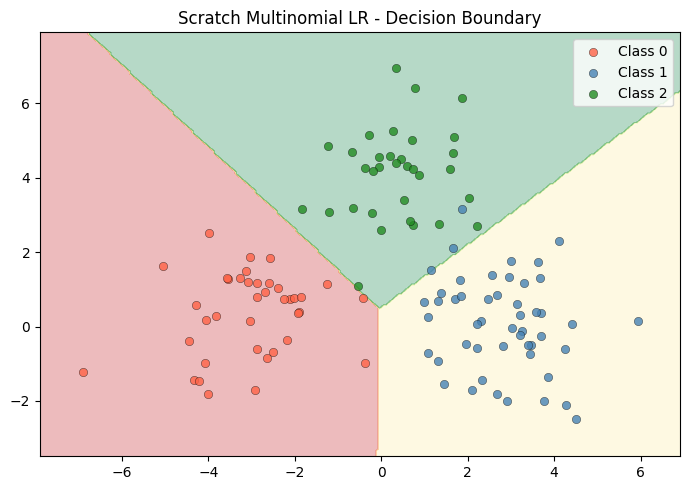

In [19]:
#@title { vertical-output: true}
class ScratchModel:
    def __init__(self, W, b):
        self.W = W
        self.b = b
    def predict(self, X):
        _, Y_hat = forward(X, self.W, self.b)
        return np.argmax(Y_hat, axis=1)

scratch_model = ScratchModel(W, b)
plot_decision_boundary(scratch_model, X_test, y_test,
                       title='Scratch Multinomial LR - Decision Boundary')

---
## Part 6: Iris 데이터셋 적용 (15점)

실제 벤치마크 데이터인 Iris 데이터셋에 직접 구현한 모델을 적용합니다.

- 4개 feature (꽃받침·꽃잎 길이/너비)
- 3개 클래스 (Setosa, Versicolor, Virginica)
- 총 150 샘플

---

### 문제 6-1. Iris 데이터 준비 및 정규화 [5점]

**문제:** Iris 데이터를 로드하고, train/test 분할 후 훈련셋 기준으로 특성을 정규화하세요.

**예상 결과:** 훈련 120개, 테스트 30개

In [22]:
#@title { vertical-output: true}
from sklearn.datasets import load_iris

# IMPLEMENT HERE: load_iris()로 데이터 로드
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# IMPLEMENT HERE: train_test_split (test_size=0.2, random_state=42)
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# IMPLEMENT HERE: 훈련셋 기준으로 평균/표준편차 계산 후 정규화
X_mean = X_iris_train.mean(axis=0)
X_std  = X_iris_train.std(axis=0)
X_iris_train = (X_iris_train - X_mean) / X_std
X_iris_test  = (X_iris_test  - X_mean) / X_std

print(f"훈련 데이터: {X_iris_train.shape}")
print(f"테스트 데이터: {X_iris_test.shape}")

훈련 데이터: (120, 4)
테스트 데이터: (30, 4)


### 문제 6-2. 학습 및 정확도 비교 [5점]

**문제:** Iris 데이터로 모델을 학습하고, sklearn 결과와 정확도를 비교하세요. (learning_rate=0.5, n_epochs=1000)

**예상 결과:** 정확도 0.90 이상

In [26]:
#@title { vertical-output: true}
# IMPLEMENT HERE: train_multinomial_lr으로 학습 (learning_rate=0.5, n_epochs=1000)
# W_iris, b_iris, loss_iris =

# IMPLEMENT HERE: 테스트셋 예측 및 정확도 계산
# _, Y_hat_iris   =
# y_hat_iris      =
# acc_iris_search =

# IMPLEMENT HERE: sklearn LogisticRegression으로 구현
model_iris_sk = LogisticRegression(solver='lbfgs', max_iter=1000)
model_iris_sk.fit(X_iris_train, y_iris_train)

y_hat_iris = model_iris_sk.predict(X_iris_test)
acc_iris_sk = accuracy_score(y_iris_test, y_hat_iris)

print(f'Accuracy (sklearn): {acc_iris_sk:.4f}')

Accuracy (sklearn): 1.0000


### 문제 6-3. Confusion Matrix 시각화 [5점]

**문제:** confusion_matrix를 사용하여 예측 결과를 시각화하세요.

**예상 결과:** 3×3 Confusion Matrix 그래프

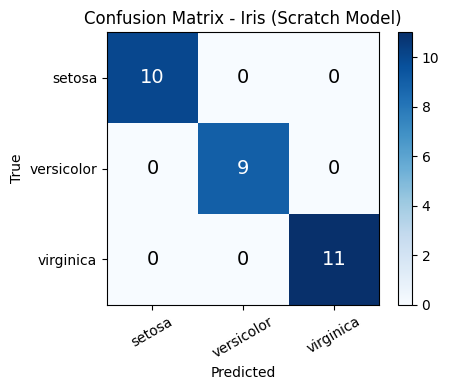

In [28]:
#@title { vertical-output: true}
# IMPLEMENT HERE: confusion_matrix 계산
cm = confusion_matrix(y_iris_test, y_hat_iris)

iris = load_iris()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
class_names = iris.target_names
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(class_names, rotation=30)
ax.set_yticklabels(class_names)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Iris (Scratch Model)')
plt.tight_layout()
plt.show()

---
## Part 7: Iris 데이터셋 응용 - 직접 구현 (15점)

Part 6에서 준비한 Iris 데이터(`X_iris_train`, `X_iris_test`, `y_iris_train`, `y_iris_test`)를 활용하여, sklearn의 `LogisticRegression` 없이 직접 구현한 함수(`train_multinomial_lr`, `forward`, `compute_gradient` 등)만으로 분류를 수행합니다.

---

### 문제 7-1. 최적 모델 학습 [8점]

**문제:** `train_multinomial_lr()`을 사용하여 Iris 데이터를 학습하세요. `learning_rate`와 `n_epochs`를 직접 선택하고, `forward()`로 예측 후 정확도를 계산하세요.

**예상 결과:** 정확도 0.93 이상

In [29]:
#@title { vertical-output: true}
# Part 6에서 준비된 X_iris_train, X_iris_test, y_iris_train, y_iris_test 사용

# IMPLEMENT HERE: learning_rate, n_epochs를 직접 설정하여 학습
W_iris7, b_iris7, loss_iris7 = train_multinomial_lr(
    X_iris_train, y_iris_train, n_classes=3,
    learning_rate= 0.1,  # 직접 설정
    n_epochs=1000,  # 직접 설정
)

# IMPLEMENT HERE: 테스트셋 예측 확률 및 클래스 계산
_, Y_hat_iris7 = forward(X_iris_test, W_iris7, b_iris7)
y_hat_iris7    = np.argmax(Y_hat_iris7, axis=1)
acc_iris7      = np.mean(y_hat_iris7 == y_iris_test)

print(f'정확도: {acc_iris7:.4f}')

Epoch  100 | Loss: 0.3393
Epoch  200 | Loss: 0.2701
Epoch  300 | Loss: 0.2292
Epoch  400 | Loss: 0.2013
Epoch  500 | Loss: 0.1811
Epoch  600 | Loss: 0.1657
Epoch  700 | Loss: 0.1536
Epoch  800 | Loss: 0.1438
Epoch  900 | Loss: 0.1358
Epoch 1000 | Loss: 0.1291
정확도: 1.0000


### 문제 7-2. 학습 결과 시각화 [7점]

**문제:** 최종 모델의 학습 곡선과 Confusion Matrix를 시각화하세요.

**예상 결과:** 감소하는 학습 곡선과 3×3 Confusion Matrix

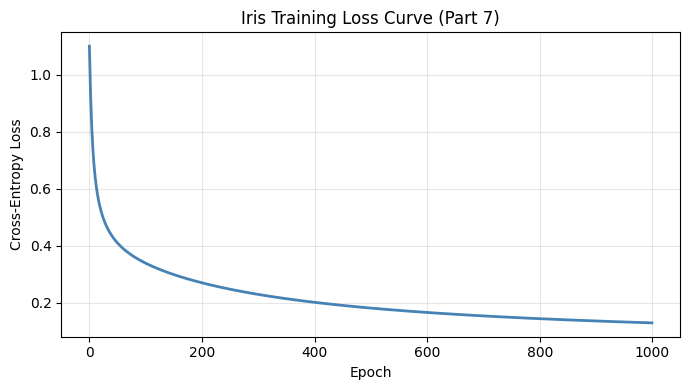

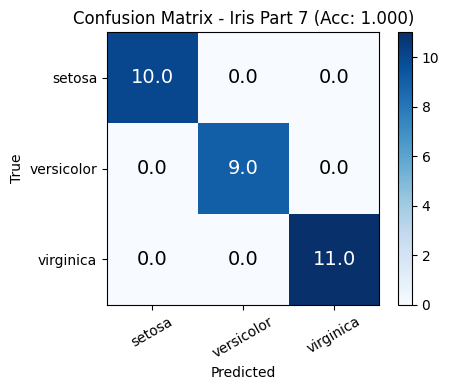

In [30]:
#@title { vertical-output: true}
# IMPLEMENT HERE: 학습 곡선 시각화 (loss_iris7 사용)
plt.figure(figsize=(7, 4))
plt.plot(loss_iris7, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Iris Training Loss Curve (Part 7)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# IMPLEMENT HERE: Confusion Matrix 계산 및 시각화
cm7 = np.zeros((3, 3))
for i in range(len(y_iris_test)):
    cm7[y_iris_test[i], y_hat_iris7[i]] += 1

iris = load_iris()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm7, cmap='Blues')
plt.colorbar(im)
class_names = iris.target_names
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(class_names, rotation=30)
ax.set_yticklabels(class_names)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm7[i, j]), ha='center', va='center',
                color='white' if cm7[i, j] > cm7.max()/2 else 'black', fontsize=14)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix - Iris Part 7 (Acc: {acc_iris7:.3f})')
plt.tight_layout()
plt.show()

---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `multinomial_logistic_regression_학번_이름.ipynb`, `multinomial_logistic_regression_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---